In [1]:
import pandas as pd
import os
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
matches = list(Path(".").rglob("prefix_cache_benchmark_sharegpt.csv"))
matches

[PosixPath('results/prefix_cache_benchmark_sharegpt.csv')]

In [3]:
df = pd.read_csv('results/prefix_cache_benchmark_sharegpt_qwen35_4b.csv')

df

,cache_type,capacity_gb,kv_cache_fraction,kv_capacity_gb,ssm_capacity_gb,kv_block_size,ssm_checkpoint_interval,num_requests,request_hit_rate,token_hit_rate,avg_hit_tokens_per_hit,total_input_tokens,total_hit_tokens,kv_used_gb,ssm_used_gb,kv_block_bytes,ssm_checkpoint_bytes,kv_cached_blocks,ssm_cached_checkpoints,evictions
0,kv_only,1.0,0.25,0.25,0.75,16,16,1238,0.159935,0.111198,808.080808,1438877,160000,0.249561,0.748683,524288,26738688,476,28,87855
1,ssm_only,1.0,0.25,0.25,0.75,16,16,1238,0.037157,0.030602,957.217391,1438877,44032,0.249561,0.748683,524288,26738688,476,28,98081
2,hybrid_intersection,1.0,0.25,0.25,0.75,16,16,1238,0.037157,0.030602,957.217391,1438877,44032,0.249561,0.748683,524288,26738688,476,28,185936
3,kv_only,1.0,0.25,0.25,0.75,16,32,1238,0.159935,0.111198,808.080808,1438877,160000,0.249561,0.748683,524288,26738688,476,28,87855
4,ssm_only,1.0,0.25,0.25,0.75,16,32,1238,0.042811,0.031380,851.924528,1438877,45152,0.249561,0.748683,524288,26738688,476,28,48554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,ssm_only,10.0,0.75,7.50,2.50,32,32,1238,0.079160,0.059402,872.163265,1438877,85472,7.499416,2.486698,1048576,26738688,7152,93,46935
212,hybrid_intersection,10.0,0.75,7.50,2.50,32,32,1238,0.079160,0.059402,872.163265,1438877,85472,7.499416,2.486698,1048576,26738688,7152,93,47175
213,kv_only,10.0,0.75,7.50,2.50,32,64,1238,0.919225,0.921608,1165.272408,1438877,1326080,7.499416,2.486698,1048576,26738688,7152,93,240
214,ssm_only,10.0,0.75,7.50,2.50,32,64,1238,0.137318,0.113644,961.882353,1438877,163520,7.499416,2.486698,1048576,26738688,7152,93,22237


In [4]:
# Convert rates to percent for easier reading.
df["request_hit_pct"] = 100 * df["request_hit_rate"]
df["token_hit_pct"] = 100 * df["token_hit_rate"]

param_cols = [
    "cache_type",
    "capacity_gb",
    "kv_cache_fraction",
    "kv_block_size",
    "ssm_checkpoint_interval",
]

print(df.shape)
display(df[param_cols + ["request_hit_pct", "token_hit_pct", "kv_used_gb", "ssm_used_gb", "evictions"]].head())

(216, 22)


,cache_type,capacity_gb,kv_cache_fraction,kv_block_size,ssm_checkpoint_interval,request_hit_pct,token_hit_pct,kv_used_gb,ssm_used_gb,evictions
0,kv_only,1.0,0.25,16,16,15.993538,11.119783,0.249561,0.748683,87855
1,ssm_only,1.0,0.25,16,16,3.715670,3.060164,0.249561,0.748683,98081
2,hybrid_intersection,1.0,0.25,16,16,3.715670,3.060164,0.249561,0.748683,185936
3,kv_only,1.0,0.25,16,32,15.993538,11.119783,0.249561,0.748683,87855
4,ssm_only,1.0,0.25,16,32,4.281099,3.138003,0.249561,0.748683,48554


In [5]:
# Overview: best configurations by token hit rate.
best = (
    df.sort_values("token_hit_rate", ascending=False)
      [param_cols + [
          "token_hit_pct",
          "request_hit_pct",
          "avg_hit_tokens_per_hit",
          "kv_used_gb",
          "ssm_used_gb",
          "evictions",
      ]]
      .head(20)
)

display(best.style.format({
    "token_hit_pct": "{:.2f}%",
    "request_hit_pct": "{:.2f}%",
    "avg_hit_tokens_per_hit": "{:.1f}",
    "kv_used_gb": "{:.3f}",
    "ssm_used_gb": "{:.3f}",
}))

,cache_type,capacity_gb,kv_cache_fraction,kv_block_size,ssm_checkpoint_interval,token_hit_pct,request_hit_pct,avg_hit_tokens_per_hit,kv_used_gb,ssm_used_gb,evictions
204,kv_only,10.000000,0.750000,16,64,92.79%,92.49%,1166.0,7.500,2.487,523
201,kv_only,10.000000,0.750000,16,32,92.79%,92.49%,1166.0,7.500,2.487,523
198,kv_only,10.000000,0.750000,16,16,92.79%,92.49%,1166.0,7.500,2.487,523
180,kv_only,10.000000,0.500000,16,16,92.74%,92.33%,1167.5,5.000,4.973,5332
183,kv_only,10.000000,0.500000,16,32,92.74%,92.33%,1167.5,5.000,4.973,5332
186,kv_only,10.000000,0.500000,16,64,92.74%,92.33%,1167.5,5.000,4.973,5332
144,kv_only,5.000000,0.750000,16,16,92.24%,90.95%,1178.7,3.750,1.230,8169
150,kv_only,5.000000,0.750000,16,64,92.24%,90.95%,1178.7,3.750,1.230,8169
147,kv_only,5.000000,0.750000,16,32,92.24%,90.95%,1178.7,3.750,1.230,8169
213,kv_only,10.000000,0.750000,32,64,92.16%,91.92%,1165.3,7.499,2.487,240


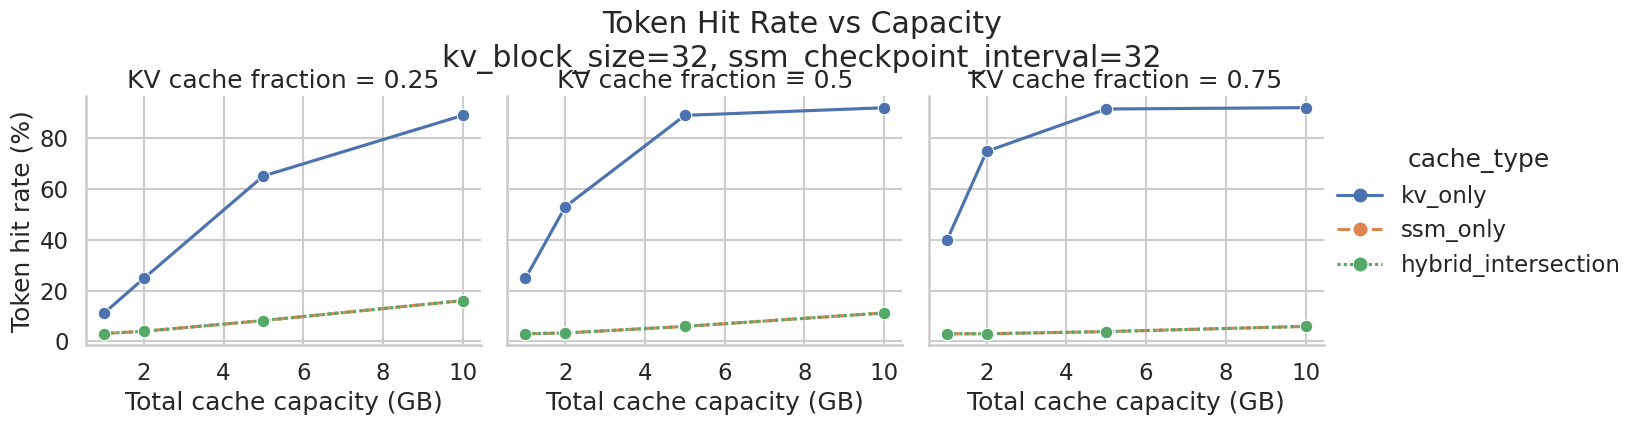

In [6]:
# Plot 1: Token hit rate vs capacity.
# Faceted by KV/SSM split. Shows all cache types.
sns.set_theme(style="whitegrid", context="talk")

plot_df = df[
    (df["kv_block_size"] == 32) &
    (df["ssm_checkpoint_interval"] == 32)
].copy()

g = sns.relplot(
    data=plot_df,
    x="capacity_gb",
    y="token_hit_pct",
    hue="cache_type",
    style="cache_type",
    col="kv_cache_fraction",
    kind="line",
    marker="o",
    height=4,
    aspect=1.15,
)

g.set_axis_labels("Total cache capacity (GB)", "Token hit rate (%)")
g.set_titles("KV cache fraction = {col_name}")
g.fig.suptitle("Token Hit Rate vs Capacity\nkv_block_size=32, ssm_checkpoint_interval=32", y=1.08)
plt.show()

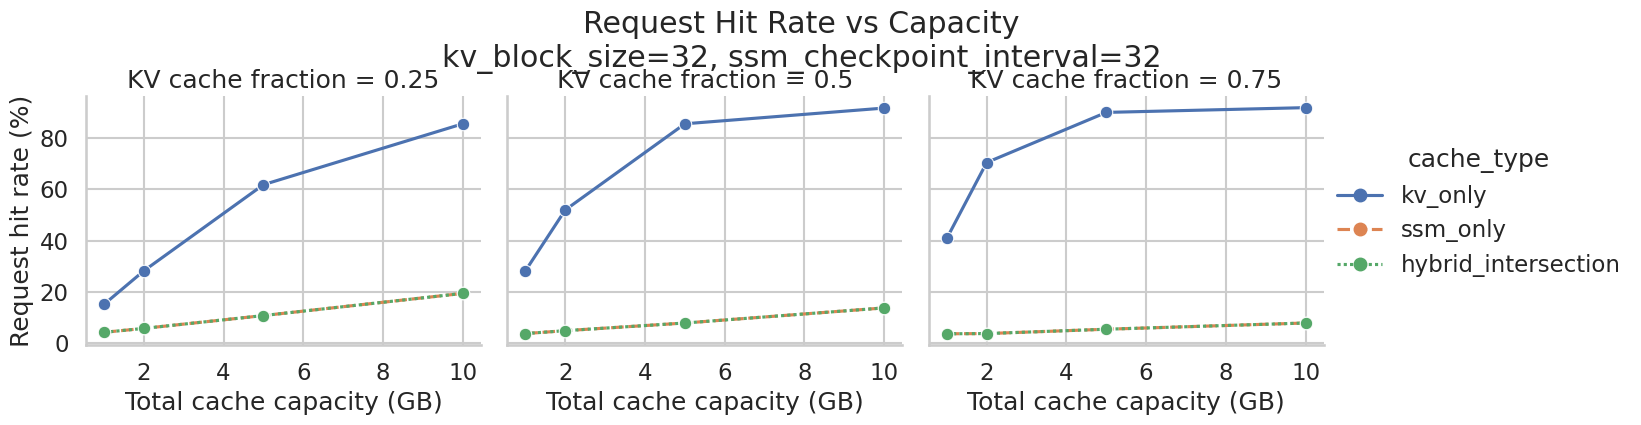

In [7]:
# Plot 2: Request hit rate vs capacity.
plot_df = df[
    (df["kv_block_size"] == 32) &
    (df["ssm_checkpoint_interval"] == 32)
].copy()

g = sns.relplot(
    data=plot_df,
    x="capacity_gb",
    y="request_hit_pct",
    hue="cache_type",
    style="cache_type",
    col="kv_cache_fraction",
    kind="line",
    marker="o",
    height=4,
    aspect=1.15,
)

g.set_axis_labels("Total cache capacity (GB)", "Request hit rate (%)")
g.set_titles("KV cache fraction = {col_name}")
g.fig.suptitle("Request Hit Rate vs Capacity\nkv_block_size=32, ssm_checkpoint_interval=32", y=1.08)
plt.show()

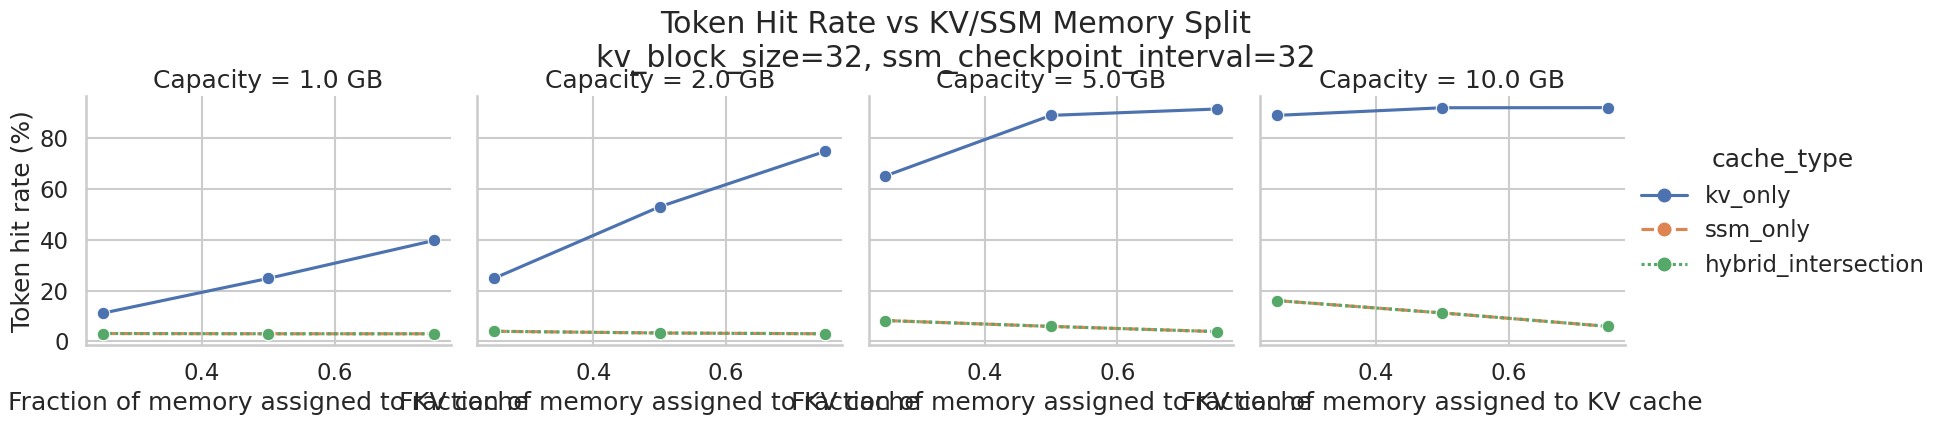

In [8]:
# Plot 3: Effect of KV/SSM memory split.
# Useful for deciding the KV-vs-SSM ratio.
plot_df = df[
    (df["kv_block_size"] == 32) &
    (df["ssm_checkpoint_interval"] == 32)
].copy()

g = sns.relplot(
    data=plot_df,
    x="kv_cache_fraction",
    y="token_hit_pct",
    hue="cache_type",
    style="cache_type",
    col="capacity_gb",
    kind="line",
    marker="o",
    height=4,
    aspect=1.05,
)

g.set_axis_labels("Fraction of memory assigned to KV cache", "Token hit rate (%)")
g.set_titles("Capacity = {col_name} GB")
g.fig.suptitle("Token Hit Rate vs KV/SSM Memory Split\nkv_block_size=32, ssm_checkpoint_interval=32", y=1.08)
plt.show()

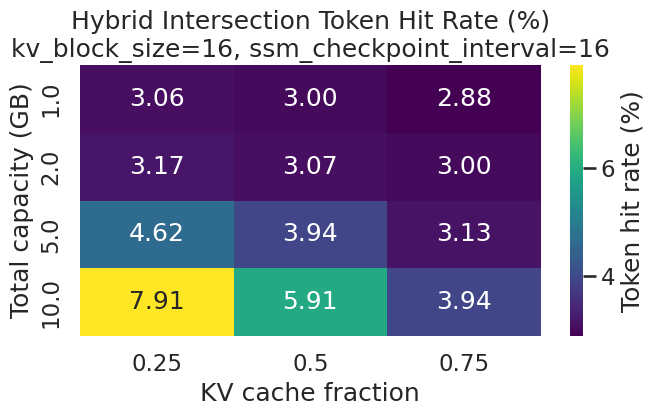

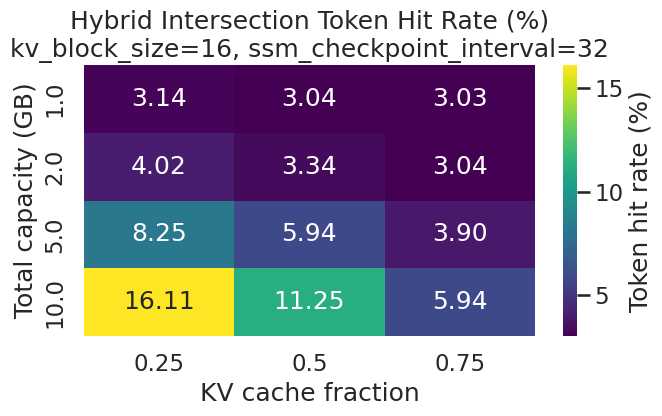

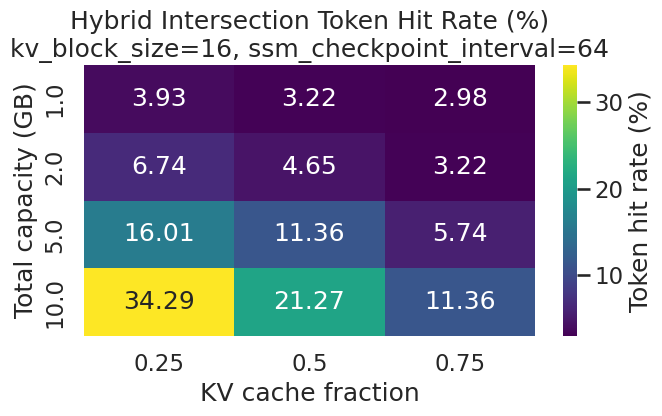

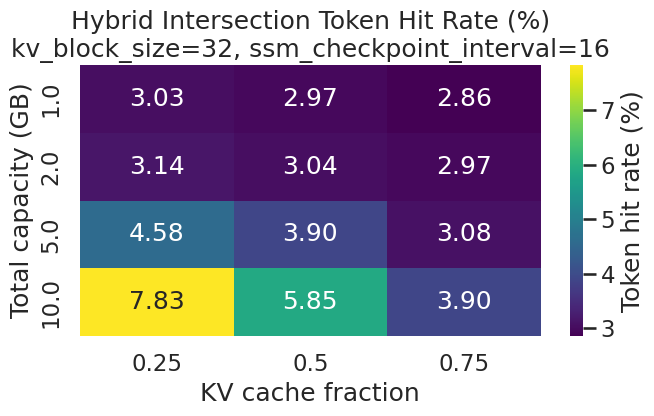

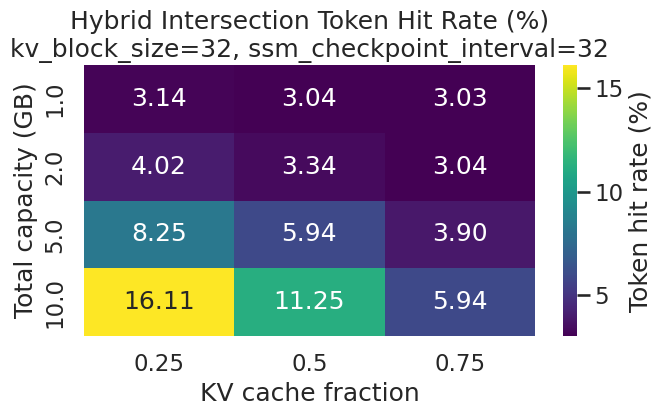

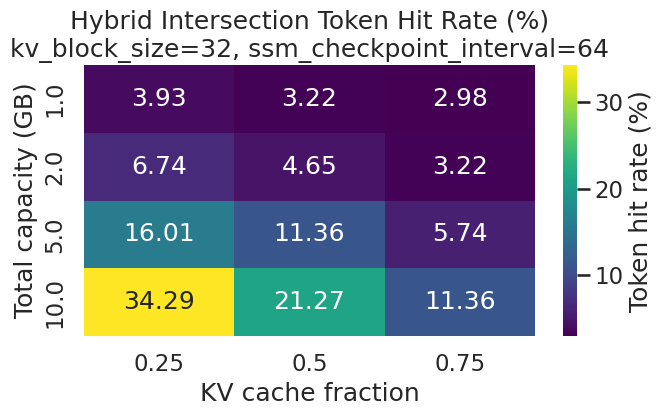

In [9]:
# Plot 4: Hybrid token hit heatmaps.
# One heatmap per block/checkpoint pair.
hybrid = df[df["cache_type"] == "hybrid_intersection"].copy()

for kv_bs in sorted(hybrid["kv_block_size"].unique()):
    for ssm_int in sorted(hybrid["ssm_checkpoint_interval"].unique()):
        h = hybrid[
            (hybrid["kv_block_size"] == kv_bs) &
            (hybrid["ssm_checkpoint_interval"] == ssm_int)
        ]

        pivot = h.pivot_table(
            index="capacity_gb",
            columns="kv_cache_fraction",
            values="token_hit_pct",
            aggfunc="mean",
        )

        plt.figure(figsize=(7, 4.5))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".2f",
            cmap="viridis",
            cbar_kws={"label": "Token hit rate (%)"},
        )
        plt.title(
            f"Hybrid Intersection Token Hit Rate (%)\n"
            f"kv_block_size={kv_bs}, ssm_checkpoint_interval={ssm_int}"
        )
        plt.xlabel("KV cache fraction")
        plt.ylabel("Total capacity (GB)")
        plt.tight_layout()
        plt.show()

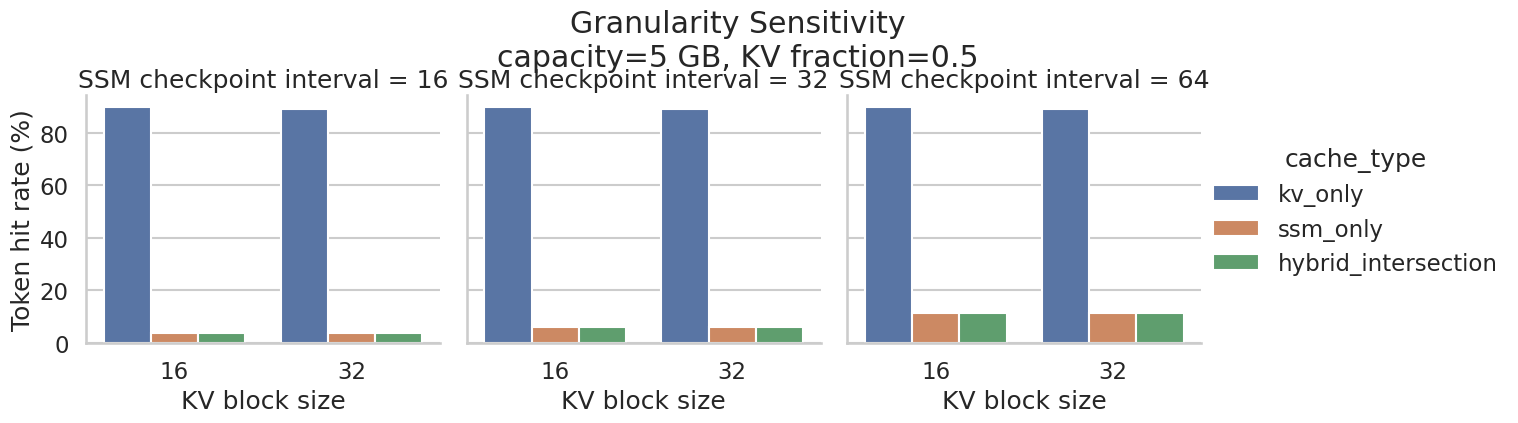

In [10]:
# Plot 5: Block/checkpoint granularity sensitivity.
# Fixed capacity and memory split; adjust these if needed.
FIXED_CAPACITY_GB = 5
FIXED_KV_FRACTION = 0.5

plot_df = df[
    (df["capacity_gb"] == FIXED_CAPACITY_GB) &
    (df["kv_cache_fraction"] == FIXED_KV_FRACTION)
].copy()

g = sns.catplot(
    data=plot_df,
    x="kv_block_size",
    y="token_hit_pct",
    hue="cache_type",
    col="ssm_checkpoint_interval",
    kind="bar",
    height=4,
    aspect=1.05,
)

g.set_axis_labels("KV block size", "Token hit rate (%)")
g.set_titles("SSM checkpoint interval = {col_name}")
g.fig.suptitle(
    f"Granularity Sensitivity\ncapacity={FIXED_CAPACITY_GB} GB, KV fraction={FIXED_KV_FRACTION}",
    y=1.08,
)
plt.show()

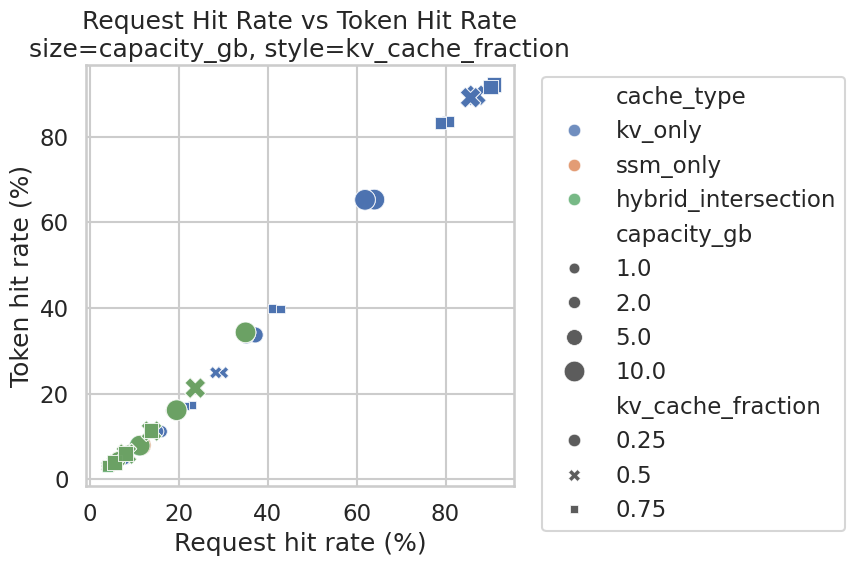

In [15]:
# Plot 6: Token hit rate vs request hit rate.
# Helps separate "many small hits" from "fewer large hits".
plot_df = df.copy()

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x="request_hit_pct",
    y="token_hit_pct",
    hue="cache_type",
    style="kv_cache_fraction",
    size="capacity_gb",
    sizes=(60, 220),
    alpha=0.8,
)

plt.xlabel("Request hit rate (%)")
plt.ylabel("Token hit rate (%)")
plt.title("Request Hit Rate vs Token Hit Rate\nsize=capacity_gb, style=kv_cache_fraction")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()
plt.show()

,cache_type,capacity_gb,kv_cache_fraction,kv_block_size,ssm_checkpoint_interval,token_hit_pct,request_hit_pct,avg_hit_tokens_per_hit,kv_used_gb,ssm_used_gb,evictions
0,hybrid_intersection,1.000000,0.250000,16,64,3.93%,5.57%,819.9,0.250,0.723,117451
1,hybrid_intersection,2.000000,0.250000,32,64,6.60%,8.80%,870.8,0.499,1.473,66635
2,hybrid_intersection,5.000000,0.250000,32,64,16.01%,18.82%,988.8,1.250,3.724,54207
3,hybrid_intersection,10.000000,0.250000,16,64,34.29%,34.98%,1139.6,2.500,7.474,54051


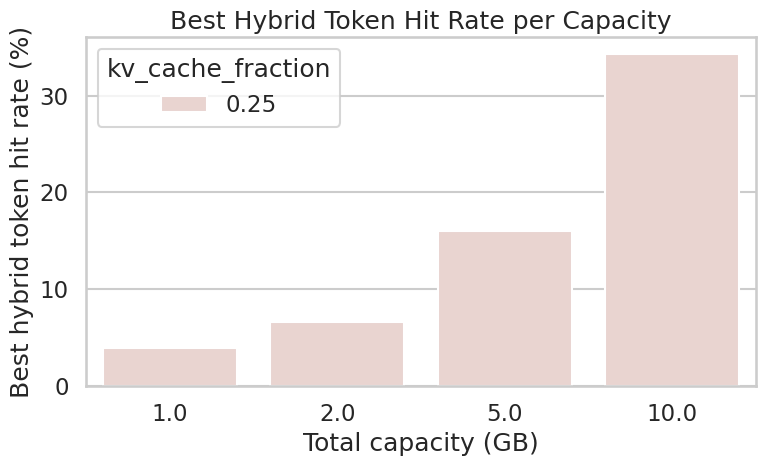

In [16]:
# Plot 7: Best hybrid config per capacity.
hybrid_best = (
    df[df["cache_type"] == "hybrid_intersection"]
    .sort_values("token_hit_rate", ascending=False)
    .groupby("capacity_gb", as_index=False)
    .first()
)

display(hybrid_best[param_cols + [
    "token_hit_pct",
    "request_hit_pct",
    "avg_hit_tokens_per_hit",
    "kv_used_gb",
    "ssm_used_gb",
    "evictions",
]].style.format({
    "token_hit_pct": "{:.2f}%",
    "request_hit_pct": "{:.2f}%",
    "avg_hit_tokens_per_hit": "{:.1f}",
    "kv_used_gb": "{:.3f}",
    "ssm_used_gb": "{:.3f}",
}))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=hybrid_best,
    x="capacity_gb",
    y="token_hit_pct",
    hue="kv_cache_fraction",
)

plt.xlabel("Total capacity (GB)")
plt.ylabel("Best hybrid token hit rate (%)")
plt.title("Best Hybrid Token Hit Rate per Capacity")
plt.tight_layout()
plt.show()